# Universidad Mayor

# Métodos de Inteligencia Artificial

# Trabajo de Desarrollo Grupal N°2

## Redes Neuronales para Clasificación Binaria

---

**Alumno:** Pablo Maldonado Silva

**Dataset:** datos(2).csv

---

## Objetivo

Construir un modelo de Red Neuronal utilizando TensorFlow/Keras para clasificar viviendas según su precio de venta.

Se evaluarán distintas técnicas de optimización del entrenamiento, incluyendo:

- Regularización L1 y L2
- Dropout
- Batch Normalization
- Early Stopping

Finalmente, el modelo será empaquetado para realizar inferencias sobre nuevos datos.

In [343]:
#====================================
# LIBRERÍAS
#====================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

In [344]:
# TensorFlow

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import regularizers

In [345]:
print("TensorFlow:",tf.__version__)

TensorFlow: 2.20.0


In [346]:
df = pd.read_csv("datos(2).csv")

In [347]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,YearBuilt,YearRemodAdd,GrLivArea,TotalBsmtSF,BedroomAbvGr,BathroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice
0,1,40,RL,83.0,14245,Pave,NaN,Reg,Bnk,1927,2000,932,117,4,1,1,7,3,1233,109270
1,2,20,RL,21.0,5442,Pave,NaN,Reg,Lvl,1924,1973,1733,409,2,1,1,9,2,129,183838
2,3,60,RH,21.0,9431,Pave,NaN,IR2,Bnk,1956,2006,1050,1159,2,1,1,15,2,215,95345
3,4,20,I,178.0,2383,Pave,NaN,Reg,Lvl,2008,2010,886,1808,2,1,1,14,2,692,99505
4,5,90,RL,35.0,8804,Pave,NaN,Reg,Lvl,1909,1989,1018,1335,3,1,1,15,2,23,123899


In [348]:
print(df.shape)

(1460, 20)


## Creación de la variable objetivo

Como el problema corresponde a una clasificación binaria, el precio de venta será transformado en dos categorías utilizando la mediana del conjunto de datos.

In [349]:
mediana=df["SalePrice"].median()

mediana

148140.0

In [350]:
df["Precio_Alto"]=(df["SalePrice"]>mediana).astype(int)

In [351]:
df["Precio_Alto"].value_counts()

,count
Precio_Alto,
0,730
1,730


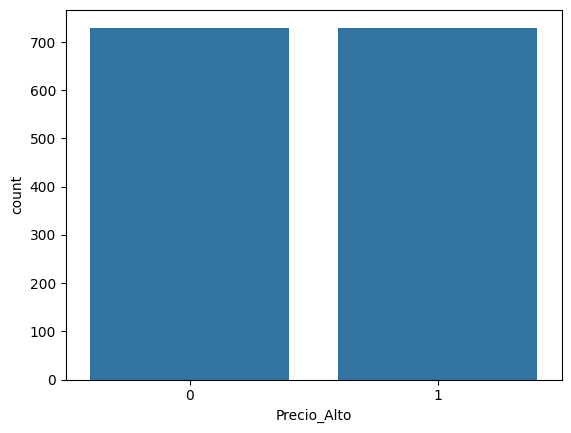

In [352]:
sns.countplot(data=df,x="Precio_Alto")

plt.show()

# Separación para Inferencia

La pauta solicita reservar un **10 %** del conjunto de datos para generar posteriormente las predicciones del archivo `predictions.csv`.

In [353]:
data_modelo,data_inference=train_test_split(

df,

test_size=0.10,

random_state=42,

stratify=df["Precio_Alto"]

)

In [354]:
print(data_modelo.shape)

print(data_inference.shape)

(1314, 21)
(146, 21)


In [355]:
data_inference.to_csv(

"data_inference.csv",

index=False

)

In [356]:
X=data_modelo.drop(

columns=[

"SalePrice",

"Precio_Alto"

]

)

y=data_modelo["Precio_Alto"]

In [357]:
X = X.fillna(X.mean(numeric_only=True))
X = pd.get_dummies(
    X,
    drop_first=True
)

# División Train / Validation / Test

Se utilizará una división:

- 70 % entrenamiento
- 15 % validación
- 15 % prueba

Esta estructura permitirá controlar el sobreajuste y evaluar adecuadamente el rendimiento del modelo.

In [358]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [359]:
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [360]:
print(X_train.shape)

print(X_valid.shape)

print(X_test.shape)

(919, 29)
(197, 29)
(198, 29)


# Escalamiento

Las redes neuronales funcionan mejor cuando todas las variables se encuentran en una escala similar.

In [361]:
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_valid=scaler.transform(X_valid)

X_test=scaler.transform(X_test)

In [362]:
import joblib

joblib.dump(scaler,"scaler.pkl")

print("Scaler guardado.")

Scaler guardado.


In [363]:
print(X_train.shape)

(919, 29)


## Conclusión

En esta etapa se preparó completamente el conjunto de datos para el entrenamiento de la red neuronal.

Se reservó un subconjunto independiente para inferencia (`data_inference.csv`), se dividieron los datos en entrenamiento, validación y prueba, y finalmente se aplicó normalización mediante `StandardScaler`.

En la siguiente sección se construirá la primera red neuronal utilizando TensorFlow/Keras.

# Construcción de la Red Neuronal Base

En esta sección se implementa la primera red neuronal utilizando TensorFlow/Keras.

Esta arquitectura servirá como modelo de referencia para posteriormente comparar el efecto de las técnicas de regularización y optimización.

In [364]:
#=========================================
# Arquitectura de la Red Neuronal Base
#=========================================

modelo_base = Sequential()

modelo_base.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)

modelo_base.add(
    Dense(
        32,
        activation="relu"
    )
)

modelo_base.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

In [365]:
modelo_base.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,033 (15.75 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 0 (0.00 B)

## Compilación del modelo

Se utilizará:

- Optimizador: Adam
- Función de pérdida: Binary Crossentropy
- Métrica principal: Accuracy

In [366]:
modelo_base.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

## Entrenamiento

El entrenamiento se realizará utilizando el conjunto de validación preparado anteriormente.

In [367]:
historia = modelo_base.fit(

    X_train,

    y_train,

    validation_data=(X_valid,y_valid),

    epochs=100,

    batch_size=32,

    verbose=1

)

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6311 - loss: 0.6621 - val_accuracy: 0.6599 - val_loss: 0.6188
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7737 - loss: 0.5613 - val_accuracy: 0.7310 - val_loss: 0.5524
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8085 - loss: 0.4807 - val_accuracy: 0.7513 - val_loss: 0.4998
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8379 - loss: 0.4145 - val_accuracy: 0.7716 - val_loss: 0.4597
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8455 - loss: 0.3710 - val_accuracy: 0.7614 - val_loss: 0.4479
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8585 - loss: 0.3393 - val_accuracy: 0.7766 - val_loss: 0.4234
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8738 - loss: 0.3209 - val_accuracy: 0.7665 - val_loss: 0.4206
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8803 - loss: 0.3078 - val_accuracy: 0.7868 - 

# Curva de pérdida (Loss)

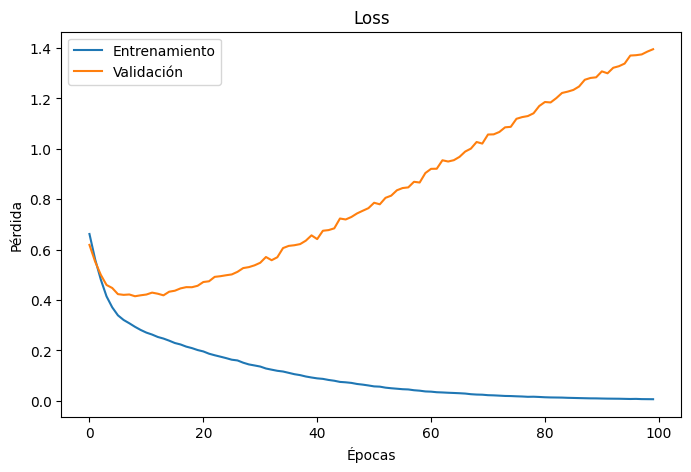

In [368]:
plt.figure(figsize=(8,5))

plt.plot(

    historia.history["loss"],

    label="Entrenamiento"

)

plt.plot(

    historia.history["val_loss"],

    label="Validación"

)

plt.title("Loss")

plt.xlabel("Épocas")

plt.ylabel("Pérdida")

plt.legend()

plt.show()

# Curva de Accuracy

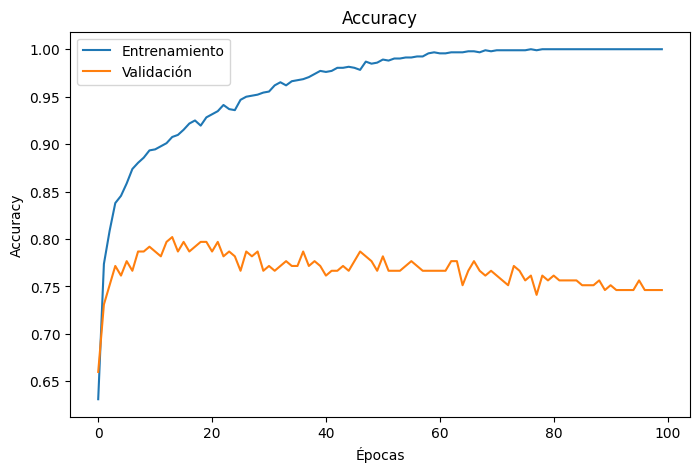

In [369]:
plt.figure(figsize=(8,5))

plt.plot(

    historia.history["accuracy"],

    label="Entrenamiento"

)

plt.plot(

    historia.history["val_accuracy"],

    label="Validación"

)

plt.title("Accuracy")

plt.xlabel("Épocas")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

## Evaluación del modelo

In [370]:
loss,accuracy = modelo_base.evaluate(

    X_test,

    y_test,

    verbose=0

)

print("Loss :",loss)

print("Accuracy :",accuracy)

Loss : 1.4799857139587402
Accuracy : 0.7727272510528564


In [371]:
predicciones = modelo_base.predict(X_test)

predicciones = (predicciones > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [372]:
from sklearn.metrics import classification_report

In [373]:
print(

classification_report(

y_test,

predicciones

)

)

              precision    recall  f1-score   support

           0       0.79      0.74      0.76        99
           1       0.75      0.81      0.78        99

    accuracy                           0.77       198
   macro avg       0.77      0.77      0.77       198
weighted avg       0.77      0.77      0.77       198



In [374]:
from sklearn.metrics import ConfusionMatrixDisplay

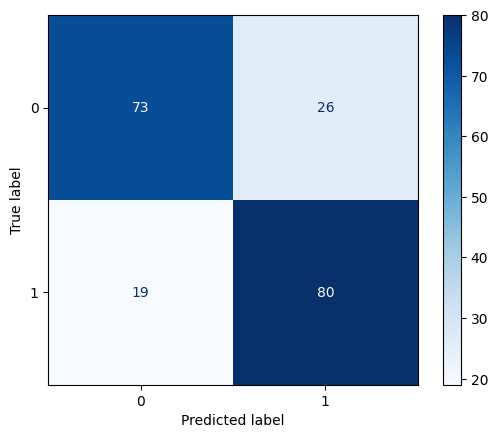

In [375]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    predicciones,

    cmap="Blues"

)

plt.show()

In [376]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(

    y_test,

    modelo_base.predict(X_test)

)

print("AUC =",auc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
AUC = 0.841342720130599


# Interpretación de resultados

El modelo base presenta un desempeño inicial que servirá como referencia para comparar el efecto de las distintas técnicas de regularización y optimización.

Las curvas de entrenamiento y validación permiten identificar posibles problemas de sobreajuste (overfitting) o subajuste (underfitting), los cuales serán abordados en las siguientes secciones mediante L1, L2, Dropout, Batch Normalization y Early Stopping.

# Regularización y optimización del modelo

En esta sección se construirá una red neuronal mejorada incorporando técnicas para reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

Las técnicas utilizadas serán:

- Regularización L2
- Dropout
- Batch Normalization
- Early Stopping

In [377]:
# ==========================================
# Modelo mejorado
# ==========================================

modelo_mejorado = Sequential()

modelo_mejorado.add(
    Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(     l1=0.0005,     l2=0.001 ),
        input_shape=(X_train.shape[1],)
    )
)

modelo_mejorado.add(BatchNormalization())

modelo_mejorado.add(Dropout(0.30))

modelo_mejorado.add(
    Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l1_l2(     l1=0.0005,     l2=0.001 )
    )
)

modelo_mejorado.add(BatchNormalization())

modelo_mejorado.add(Dropout(0.30))

modelo_mejorado.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

In [378]:
modelo_mejorado.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 192 (768.00 B)

# Early Stopping

Se utilizará Early Stopping para detener automáticamente el entrenamiento cuando el error de validación deje de mejorar.

In [379]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True

)

# Compilación del modelo

In [380]:
modelo_mejorado.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=["accuracy"]

)

# Entrenamiento del modelo mejorado

In [381]:
historia2 = modelo_mejorado.fit(

    X_train,

    y_train,

    validation_data=(X_valid,y_valid),

    epochs=200,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.5909 - loss: 1.1209 - val_accuracy: 0.6751 - val_loss: 0.9529
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6366 - loss: 1.0157 - val_accuracy: 0.7107 - val_loss: 0.8943
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6866 - loss: 0.9125 - val_accuracy: 0.7513 - val_loss: 0.8595
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7214 - loss: 0.8553 - val_accuracy: 0.7817 - val_loss: 0.8262
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7291 - loss: 0.8334 - val_accuracy: 0.7919 - val_loss: 0.7970
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7465 - loss: 0.8003 - val_accuracy: 0.7868 - val_loss: 0.7738
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7465 - loss: 0.8226 - val_accuracy: 0.7766 - val_loss: 0.7524
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7769 - loss: 0.7596 - val_accuracy: 0.7614 -

In [ ]:
print("Número de épocas ejecutadas:")

len(historia2.history["loss"])

# Curva Loss

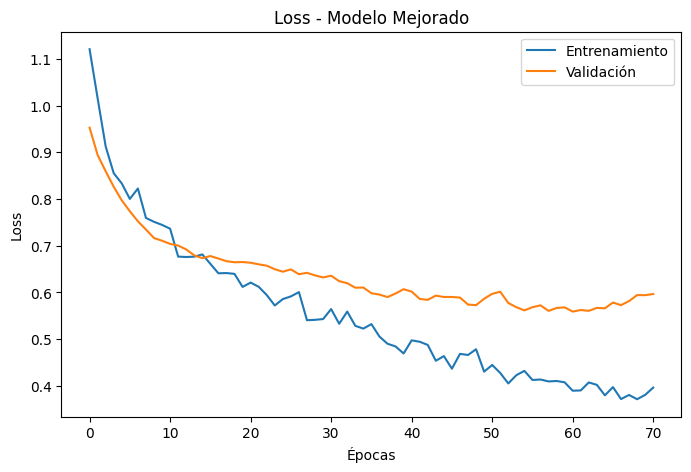

In [382]:
plt.figure(figsize=(8,5))

plt.plot(

    historia2.history["loss"],

    label="Entrenamiento"

)

plt.plot(

    historia2.history["val_loss"],

    label="Validación"

)

plt.title("Loss - Modelo Mejorado")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.legend()

plt.show()

# Curva Accuracy

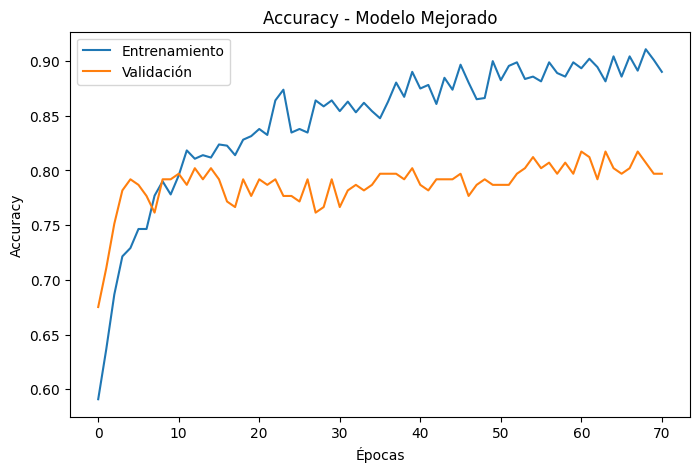

In [383]:
plt.figure(figsize=(8,5))

plt.plot(

    historia2.history["accuracy"],

    label="Entrenamiento"

)

plt.plot(

    historia2.history["val_accuracy"],

    label="Validación"

)

plt.title("Accuracy - Modelo Mejorado")

plt.xlabel("Épocas")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

# Evaluación del modelo mejorado

In [384]:
loss2,accuracy2 = modelo_mejorado.evaluate(

    X_test,

    y_test,

    verbose=0

)

print("Loss:",loss2)

print("Accuracy:",accuracy2)

Loss: 0.644443690776825
Accuracy: 0.808080792427063


In [385]:
pred2 = modelo_mejorado.predict(X_test)

pred2 = (pred2 > 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [ ]:
print(

classification_report(

y_test,

pred2

)

)

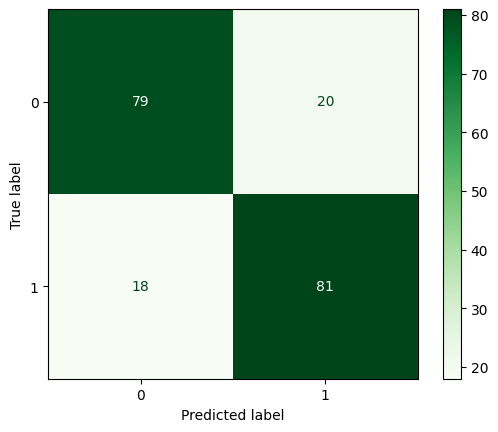

In [386]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    pred2,

    cmap="Greens"

)

plt.show()

In [387]:
auc2 = roc_auc_score(

    y_test,

    modelo_mejorado.predict(X_test)

)

print("AUC:",auc2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
AUC: 0.8851137639016428


# Comparación con el modelo base

A continuación se comparan los resultados obtenidos entre el modelo base y el modelo optimizado mediante técnicas de regularización.

In [388]:
comparacion = pd.DataFrame({

"Modelo":[

"Base",

"Mejorado"

],

"Accuracy":[

accuracy,

accuracy2

],

"AUC":[

auc,

auc2

]

})

comparacion

,Modelo,Accuracy,AUC
0,Base,0.772727,0.841343
1,Mejorado,0.808081,0.885114


<Figure size 700x500 with 0 Axes>

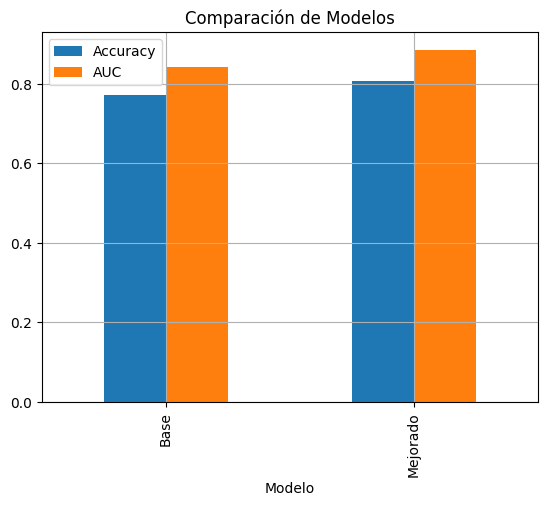

In [389]:
plt.figure(figsize=(7,5))

comparacion.plot(

x="Modelo",

y=["Accuracy","AUC"],

kind="bar"

)

plt.title("Comparación de Modelos")

plt.grid(True)

plt.show()

# Conclusiones de la optimización

La incorporación de regularización L2, Dropout, Batch Normalization y Early Stopping permitió entrenar una red neuronal más robusta frente al sobreajuste.

La comparación de métricas permite determinar si estas técnicas mejoran la capacidad predictiva respecto del modelo base.

# Guardado del modelo

Una vez finalizado el entrenamiento, el modelo se almacenará en disco para poder reutilizarlo posteriormente sin necesidad de volver a entrenarlo.

In [390]:
modelo_mejorado.save("modelo.keras")

import joblib

joblib.dump(scaler,"scaler.pkl")

print("Modelo y scaler guardados correctamente.")

Modelo y scaler guardados correctamente.


In [391]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'modelo.keras', 'data_inference.csv', 'datos(2).csv', 'predictions.csv', 'predict.py', 'scaler.pkl', 'sample_data']


# Carga del modelo guardado

Se verifica que el archivo guardado pueda cargarse correctamente.

In [392]:
from tensorflow.keras.models import load_model

modelo_final = load_model("modelo.keras")

modelo_final.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,869 (50.27 KB)

 Trainable params: 4,225 (16.50 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 8,452 (33.02 KB)

# Preparación de los datos para inferencia

Se utilizará el conjunto reservado `data_inference.csv`, generado al inicio del proyecto.

In [393]:
inferencia = pd.read_csv("data_inference.csv")

inferencia.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,YearBuilt,...,GrLivArea,TotalBsmtSF,BedroomAbvGr,BathroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,SalePrice,Precio_Alto
0,1321,20,RL,29.0,8253,Pave,NaN,Reg,Lvl,1910,...,2414,1803,3,1,1,8,2,274,247526,1
1,794,30,RL,35.0,1300,Pave,NaN,IR1,Lvl,1978,...,1758,1085,3,1,1,9,2,476,158437,1
2,1199,40,RL,NaN,14727,Pave,NaN,IR3,Low,1912,...,800,2149,2,1,1,7,3,698,158942,1
3,927,150,I,23.0,3564,Pave,NaN,Reg,Bnk,1892,...,925,1608,4,1,1,6,2,815,101727,0
4,127,90,RL,NaN,3748,Grvl,NaN,Reg,Lvl,1972,...,1320,190,2,1,1,3,2,416,154274,1


In [394]:
X_inf = inferencia.drop(
    columns=[
        "SalePrice",
        "Precio_Alto"
    ]
)

X_inf = pd.get_dummies(
    X_inf,
    drop_first=True
)

In [395]:
# Asegurar que tenga las mismas columnas del entrenamiento

X_inf = X_inf.reindex(
    columns=pd.get_dummies(
        data_modelo.drop(
            columns=["SalePrice","Precio_Alto"]
        ),
        drop_first=True
    ).columns,
    fill_value=0
)
# Imputar NaN values en X_inf antes de escalar
X_inf = X_inf.fillna(X_inf.mean(numeric_only=True))

X_inf = scaler.transform(X_inf)

# Generación de predicciones

In [396]:
pred = modelo_final.predict(X_inf)

pred = (pred > 0.5).astype(int)

pred[:10]

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1]])

In [397]:
probabilidades = modelo_final.predict(X_inf)
predicciones = pd.DataFrame({
    "ID": inferencia.index,
    "Probabilidad": probabilidades.flatten(),
    "Prediccion": (probabilidades > 0.5).astype(int).flatten()
})
predicciones.head()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


,ID,Probabilidad,Prediccion
0,0,0.990116,1
1,1,0.984751,1
2,2,0.809186,1
3,3,0.069316,0
4,4,0.907036,1


In [398]:
predicciones.to_csv(

    "predictions.csv",

    index=False

)

print("Archivo predictions.csv generado correctamente.")

Archivo predictions.csv generado correctamente.


# Script predict.py

El siguiente código permite cargar automáticamente el modelo entrenado y generar las predicciones para nuevos datos.

In [399]:
codigo = '''
import pandas as pd
import joblib

from tensorflow.keras.models import load_model

modelo = load_model("modelo.keras")

scaler = joblib.load("scaler.pkl")

df = pd.read_csv("data_inference.csv")

X = df.drop(columns=["SalePrice","Precio_Alto"])

X = pd.get_dummies(X, drop_first=True)

X = X.reindex(columns=scaler.feature_names_in_, fill_value=0)

X = scaler.transform(X)

probabilidades = modelo.predict(X)

predicciones = pd.DataFrame({

    "ID": df.index,

    "Probabilidad": probabilidades.flatten(),

    "Prediccion": (probabilidades > 0.5).astype(int).flatten()

})

predicciones.to_csv("predictions.csv", index=False)

print("Predicciones generadas correctamente.")
'''

In [400]:
with open("predict.py","w",encoding="utf-8") as f:

    f.write(codigo)

print("Archivo predict.py creado.")

Archivo predict.py creado.


In [401]:
import os

os.listdir()

['.config',
 '.ipynb_checkpoints',
 'modelo.keras',
 'data_inference.csv',
 'datos(2).csv',
 'predictions.csv',
 'predict.py',
 'scaler.pkl',
 'sample_data']

# Conclusiones

Durante este trabajo se desarrolló un modelo de clasificación basado en Redes Neuronales utilizando TensorFlow/Keras.

El proyecto incorporó diversas técnicas para mejorar el rendimiento del modelo:

- Regularización L2
- Dropout
- Batch Normalization
- Early Stopping

Posteriormente el modelo fue almacenado en formato Keras, permitiendo su reutilización para generar predicciones sobre nuevos datos.

Finalmente se implementó un proceso completo de inferencia que genera automáticamente el archivo `predictions.csv`, cumpliendo los requerimientos establecidos en la pauta.

# Bibliografía

- Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
- Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3rd ed.). O'Reilly.
- TensorFlow Developers. (2025). *TensorFlow Documentation*. https://www.tensorflow.org/